In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harlfoxem/housesalesprediction/kc_house_data.csv


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import shap

Проведем первичный анализ, чтобы определить выбросы, пропуск, другие анамалии

In [3]:
df =  pd.read_csv('/kaggle/input/datasets/harlfoxem/housesalesprediction/kc_house_data.csv')

**Первичный анализ датасета**

In [4]:
columns = list(df)
columns

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

In [5]:
print(f'Количество пропусков {df.isna().sum()}')

Количество пропусков id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [6]:
print(f'Количество дублирующихся id {df.duplicated(subset=['id']).sum()}')

Количество дублирующихся id 177


In [7]:
df.describe().T[['min', 'max', 'mean', '50%']]

,min,max,mean,50%
id,1.000102e+06,9.900000e+09,4.580302e+09,3.904930e+09
price,7.500000e+04,7.700000e+06,5.400881e+05,4.500000e+05
bedrooms,0.000000e+00,3.300000e+01,3.370842e+00,3.000000e+00
bathrooms,0.000000e+00,8.000000e+00,2.114757e+00,2.250000e+00
sqft_living,2.900000e+02,1.354000e+04,2.079900e+03,1.910000e+03
sqft_lot,5.200000e+02,1.651359e+06,1.510697e+04,7.618000e+03
floors,1.000000e+00,3.500000e+00,1.494309e+00,1.500000e+00
waterfront,0.000000e+00,1.000000e+00,7.541757e-03,0.000000e+00
view,0.000000e+00,4.000000e+00,2.343034e-01,0.000000e+00
condition,1.000000e+00,5.000000e+00,3.409430e+00,3.000000e+00


In [8]:
print(df['bedrooms'].value_counts().sort_index())
print(f"Площадь помещения с 33 комнатами {df.loc[df['bedrooms']==33, 'sqft_living'].item()} индекс {df[df['bedrooms']==33].index[0]}")

bedrooms
0       13
1      199
2     2760
3     9824
4     6882
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64
Площадь помещения с 33 комнатами 1620 индекс 15870


Не может существовать квартиры с площадью 1620 и 33 комнатами => необходимо удалить аномалию

In [9]:
df.drop(15870)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


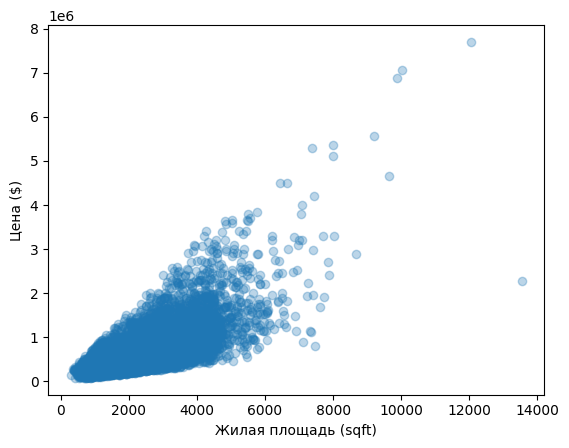

In [10]:
plt.scatter(df['sqft_living'], df['price'], alpha=0.3)
plt.xlabel('Жилая площадь (sqft)')
plt.ylabel('Цена ($)')
plt.show()

У нас есть одна точка с максимально большой площадью но низкой ценой => данное место непригодно для жилья, необходимо удалить

In [11]:
df = df[~((df['sqft_living'] > 13000) & (df['price'] < 3000000))]

In [12]:
outlier = df[df['sqft_living'] > 10000]
print(outlier[['price', 'sqft_living', 'bedrooms', 'bathrooms', 'zipcode']])

          price  sqft_living  bedrooms  bathrooms  zipcode
3914  7062500.0        10040         5        4.5    98004
7252  7700000.0        12050         6        8.0    98102


In [13]:
print(f'Дома без ванной комнаты, {len(df[df['bathrooms']==0])}')
print(f'Дома без спальни, {len(df[df['bedrooms']==0])}')

Дома без ванной комнаты, 10
Дома без спальни, 13


не может существовать дома без спальни или ванной комнаты => необходимо удалить такие строки

In [14]:
df = df[(df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

In [15]:
print(f'Дома без ванной комнаты, {len(df[df['bathrooms']==0])}')
print(f'Дома без спальни, {len(df[df['bedrooms']==0])}')

Дома без ванной комнаты, 0
Дома без спальни, 0


In [16]:
df['price_log'] = np.log1p(df['price'])

In [17]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price_log
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,12.309987
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,13.195616
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,12.100718
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,13.311331
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,13.142168


**Первичный анализ датасета:** 
1) убрали выбросы
2) удалили логические ошибки (дома без ванн и спален, 33 комнаты)
3) Создали колонку с ценой переведенной в логарифм, для того чтобы уравнят влияния средней цены и максимальной, а также оптимизитровать процентную ошибку

**Дальше подготовка датасета к работе**

In [18]:
df['date'] = pd.to_datetime(df['date'])
df['sales_year'] = df['date'].dt.year
df['sales_month'] = df['date'].dt.month
df['sqft_basement'] = pd.to_numeric(df['sqft_basement'], errors='coerce').fillna(0)

In [19]:
#Возраст дома
df['house_age'] = df['sales_year'] - df['yr_built']
# Наличие ремонта(1 - был, 0 - не было)
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)
# Плотность застройки (отношение жилой к участку)
df['living_to_lot_ratio'] = df['sqft_living'] / df['sqft_lot']
# Количество санузлов на одну спальню
df['baths_per_bed'] = df['bathrooms'] / df['bedrooms']
#Наличие подвала
df['has_basement'] = (df['sqft_basement'] > 0).astype(int)
# Сравнени районов, Если >1 дома больше => лучше
df['sqft_vs_neighbors'] = df['sqft_living'] / df['sqft_living15']

# Удаляем технические колонки, которые больше не нужны 
df = df.drop(columns=['id', 'date', 'yr_renovated'])

In [20]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'price_log', 'sales_year', 'sales_month', 'house_age',
       'is_renovated', 'living_to_lot_ratio', 'baths_per_bed', 'has_basement',
       'sqft_vs_neighbors'],
      dtype='object')

In [21]:
X = df.drop(columns=['price', 'price_log'])
y = df['price_log']

In [22]:
X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test = X_train.copy(), X_test.copy()

In [23]:
#Расстояние до центра
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

In [24]:
scaler = StandardScaler()
coords_train = scaler.fit_transform(X_train[['lat', 'long']])
coords_test = scaler.transform(X_test[['lat', 'long']])

In [25]:
kmeans = KMeans(n_clusters=30, random_state=42, n_init='auto')
X_train['kmeans_cluster'] = kmeans.fit_predict(coords_train)
X_test['kmeans_cluster'] = kmeans.predict(coords_test)

In [26]:
# 1. Обучение DBSCAN 
dbscan = DBSCAN(eps=0.1, min_samples=15)
X_train['dbscan_cluster'] = dbscan.fit_predict(coords_train)

# 2. Проекция на Test через KNN
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(coords_train, X_train['dbscan_cluster'])
X_test['dbscan_cluster'] = knn.predict(coords_test)

In [27]:

seattle_lat, seattle_lon = 47.6062, -122.3321

X_train['dist_to_center'] = haversine_distance(X_train['lat'], X_train['long'], seattle_lat, seattle_lon)
X_test['dist_to_center'] = haversine_distance(X_test['lat'], X_test['long'], seattle_lat, seattle_lon)

**Обучение градиентного бустинга**

In [29]:
lgbm = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

In [30]:
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004580 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3286
[LightGBM] [Info] Number of data points in the train set: 17276, number of used features: 28
[LightGBM] [Info] Start training from score 13.047607
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

LGBMRegressor(learning_rate=0.03, max_depth=8, n_estimators=1000, n_jobs=-1,
              random_state=42)

**Оценка модели**

In [32]:

y_pred_log = lgbm.predict(X_test)

y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred_real)
mape = mean_absolute_percentage_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print(f"MAE: ${mae:,.0f}")
print(f"MAPE: {mape:.2%}")
print(f"R2 Score: {r2:.3f}")

MAE: $60,184
MAPE: 11.33%
R2 Score: 0.896


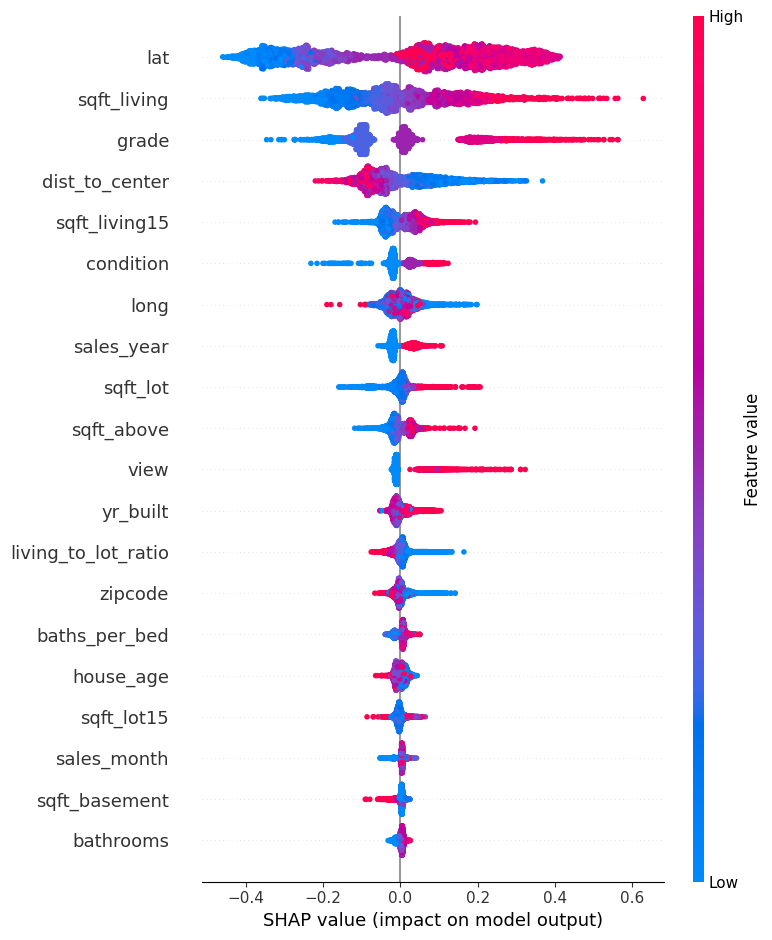

In [34]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="dot")